In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Paths
NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Load main dataset
print("Loading datasets...")
app_train = pd.read_csv(DATA_DIR / "HC_application_train.csv")
bureau = pd.read_csv(DATA_DIR / "HC_bureau.csv")
bureau_balance = pd.read_csv(DATA_DIR / "HC_bureau_balance.csv")
prev_app = pd.read_csv(DATA_DIR / "HC_previous_application.csv")

print(f"app_train:    {app_train.shape}")
print(f"bureau:       {bureau.shape}")
print(f"bureau_bal:   {bureau_balance.shape}")
print(f"prev_app:     {prev_app.shape}")
print("\nAll datasets loaded!")

Loading datasets...
app_train:    (307511, 122)
bureau:       (1716428, 17)
bureau_bal:   (27299925, 3)
prev_app:     (1670214, 37)

All datasets loaded!


In [3]:
print("=" * 50)
print("ENGINEERING CORE FINANCIAL RATIOS")
print("=" * 50)

df = app_train.copy()

# ── 1. Age & Employment ──────────────────────────────────────
df["AGE_YEARS"] = abs(df["DAYS_BIRTH"]) / 365
df["EMPLOYMENT_YEARS"] = abs(
    df["DAYS_EMPLOYED"].replace(365243, np.nan)) / 365
df["EMPLOYMENT_TO_AGE_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

# ── 2. Debt & Credit Ratios ──────────────────────────────────
df["DEBT_TO_INCOME"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_TO_INCOME"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_TO_GOODS"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"].replace(0, np.nan)
df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"].replace(0, np.nan)
df["ANNUITY_TO_CREDIT"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"].replace(0, np.nan)

# ── 3. Credit Bureau Inquiry Features ───────────────────────
df["TOTAL_INQUIRIES"] = (
    df["AMT_REQ_CREDIT_BUREAU_HOUR"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_DAY"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_WEEK"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_MON"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_QRT"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_YEAR"].fillna(0)
)
df["RECENT_INQUIRIES"] = (
    df["AMT_REQ_CREDIT_BUREAU_HOUR"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_DAY"].fillna(0) +
    df["AMT_REQ_CREDIT_BUREAU_WEEK"].fillna(0)
)

# ── 4. Document Flags ────────────────────────────────────────
doc_cols = [c for c in df.columns if "FLAG_DOCUMENT" in c]
df["TOTAL_DOCUMENTS"] = df[doc_cols].sum(axis=1)

# ── 5. External Score Features ───────────────────────────────
df["EXT_SOURCE_MEAN"] = df[["EXT_SOURCE_1",
                              "EXT_SOURCE_2",
                              "EXT_SOURCE_3"]].mean(axis=1)
df["EXT_SOURCE_STD"] = df[["EXT_SOURCE_1",
                             "EXT_SOURCE_2",
                             "EXT_SOURCE_3"]].std(axis=1)
df["EXT_SOURCE_MIN"] = df[["EXT_SOURCE_1",
                             "EXT_SOURCE_2",
                             "EXT_SOURCE_3"]].min(axis=1)
df["EXT_SOURCE_MAX"] = df[["EXT_SOURCE_1",
                             "EXT_SOURCE_2",
                             "EXT_SOURCE_3"]].max(axis=1)
df["EXT_SOURCE_RANGE"] = df["EXT_SOURCE_MAX"] - df["EXT_SOURCE_MIN"]

# ── 6. Days Features ─────────────────────────────────────────
df["DAYS_EMPLOYED_ANOMALY"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
df["ID_TO_BIRTH_RATIO"] = abs(df["DAYS_ID_PUBLISH"]) / abs(df["DAYS_BIRTH"])
df["PHONE_TO_BIRTH_RATIO"] = abs(df["DAYS_LAST_PHONE_CHANGE"]) / abs(df["DAYS_BIRTH"])
df["PHONE_TO_EMPLOY_RATIO"] = abs(df["DAYS_LAST_PHONE_CHANGE"]) / (
    abs(df["DAYS_EMPLOYED"].replace(365243, np.nan)) + 1)

# ── 7. Age Buckets ───────────────────────────────────────────
df["AGE_GROUP"] = pd.cut(
    df["AGE_YEARS"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["Very Young", "Young", "Middle", "Senior", "Elder"]
)

new_features = [
    "AGE_YEARS", "EMPLOYMENT_YEARS", "EMPLOYMENT_TO_AGE_RATIO",
    "DEBT_TO_INCOME", "ANNUITY_TO_INCOME", "CREDIT_TO_GOODS",
    "INCOME_PER_PERSON", "ANNUITY_TO_CREDIT",
    "TOTAL_INQUIRIES", "RECENT_INQUIRIES", "TOTAL_DOCUMENTS",
    "EXT_SOURCE_MEAN", "EXT_SOURCE_STD", "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX", "EXT_SOURCE_RANGE",
    "DAYS_EMPLOYED_ANOMALY", "ID_TO_BIRTH_RATIO",
    "PHONE_TO_BIRTH_RATIO", "PHONE_TO_EMPLOY_RATIO"
]

print(f"New features created: {len(new_features)}")
print("\nSample values:")
print(df[new_features[:8]].describe().round(4).to_string())

ENGINEERING CORE FINANCIAL RATIOS
New features created: 20

Sample values:
        AGE_YEARS  EMPLOYMENT_YEARS  EMPLOYMENT_TO_AGE_RATIO  DEBT_TO_INCOME  ANNUITY_TO_INCOME  CREDIT_TO_GOODS  INCOME_PER_PERSON  ANNUITY_TO_CREDIT
count 307511.0000       252137.0000              252137.0000     307511.0000        307499.0000      307233.0000        307509.0000        307499.0000
mean      43.9370            6.5320                   0.1569          3.9576             0.1809           1.1230         93105.8796             0.0537
std       11.9561            6.4065                   0.1335          2.6897             0.0946           0.1240        101373.3634             0.0225
min       20.5178            0.0000                   0.0000          0.0048             0.0002           0.1500          2812.5000             0.0221
25%       34.0082            2.1014                   0.0561          2.0187             0.1148           1.0000         47250.0000             0.0369
50%       43.1507  

In [4]:
print("=" * 50)
print("ENGINEERING BUREAU FEATURES")
print("=" * 50)

# ── Aggregate bureau.csv by SK_ID_CURR ───────────────────────
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_LOAN_COUNT        = ("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_COUNT      = ("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_COUNT      = ("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    BUREAU_TOTAL_DEBT        = ("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_TOTAL_CREDIT      = ("AMT_CREDIT_SUM", "sum"),
    BUREAU_TOTAL_OVERDUE     = ("AMT_CREDIT_SUM_OVERDUE", "sum"),
    BUREAU_MAX_OVERDUE       = ("AMT_CREDIT_SUM_OVERDUE", "max"),
    BUREAU_AVG_DAYS_CREDIT   = ("DAYS_CREDIT", "mean"),
    BUREAU_MAX_DAYS_OVERDUE  = ("CREDIT_DAY_OVERDUE", "max"),
    BUREAU_MEAN_DAYS_OVERDUE = ("CREDIT_DAY_OVERDUE", "mean"),
    BUREAU_DEBT_CREDIT_RATIO = ("AMT_CREDIT_SUM_DEBT", "sum"),
).reset_index()

# Active to total ratio
bureau_agg["BUREAU_ACTIVE_RATIO"] = (
    bureau_agg["BUREAU_ACTIVE_COUNT"] /
    bureau_agg["BUREAU_LOAN_COUNT"].replace(0, np.nan)
)

# Debt to credit ratio
bureau_agg["BUREAU_DEBT_TO_CREDIT"] = (
    bureau_agg["BUREAU_TOTAL_DEBT"] /
    bureau_agg["BUREAU_TOTAL_CREDIT"].replace(0, np.nan)
)

print(f"Bureau aggregated shape: {bureau_agg.shape}")
print(f"Unique applicants in bureau: {bureau_agg['SK_ID_CURR'].nunique():,}")

# ── Aggregate bureau_balance ──────────────────────────────────
print("\nAggregating bureau_balance (27M rows - takes ~30 secs)...")

# Map status to numeric severity
status_map = {"C": 0, "X": 0, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
bureau_balance["STATUS_NUM"] = bureau_balance["STATUS"].map(status_map)

bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(
    BB_MAX_STATUS    = ("STATUS_NUM", "max"),
    BB_MEAN_STATUS   = ("STATUS_NUM", "mean"),
    BB_COUNT         = ("STATUS_NUM", "count"),
    BB_DPD_COUNT     = ("STATUS_NUM", lambda x: (x > 0).sum()),
).reset_index()

bb_agg["BB_DPD_RATIO"] = bb_agg["BB_DPD_COUNT"] / bb_agg["BB_COUNT"]

# Merge bb_agg back to bureau
bureau_with_bb = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")

# Aggregate to applicant level
bureau_bb_agg = bureau_with_bb.groupby("SK_ID_CURR").agg(
    BB_MAX_STATUS_EVER  = ("BB_MAX_STATUS", "max"),
    BB_MEAN_STATUS      = ("BB_MEAN_STATUS", "mean"),
    BB_DPD_RATIO_MEAN   = ("BB_DPD_RATIO", "mean"),
    BB_DPD_RATIO_MAX    = ("BB_DPD_RATIO", "max"),
).reset_index()

print(f"Bureau balance aggregated shape: {bureau_bb_agg.shape}")

# ── Merge all bureau features ─────────────────────────────────
bureau_features = bureau_agg.merge(bureau_bb_agg, on="SK_ID_CURR", how="left")
print(f"Combined bureau features shape: {bureau_features.shape}")
print(f"\nBureau feature columns: {list(bureau_features.columns[1:])}")

ENGINEERING BUREAU FEATURES
Bureau aggregated shape: (305811, 14)
Unique applicants in bureau: 305,811

Aggregating bureau_balance (27M rows - takes ~30 secs)...
Bureau balance aggregated shape: (305811, 5)
Combined bureau features shape: (305811, 18)

Bureau feature columns: ['BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_CLOSED_COUNT', 'BUREAU_TOTAL_DEBT', 'BUREAU_TOTAL_CREDIT', 'BUREAU_TOTAL_OVERDUE', 'BUREAU_MAX_OVERDUE', 'BUREAU_AVG_DAYS_CREDIT', 'BUREAU_MAX_DAYS_OVERDUE', 'BUREAU_MEAN_DAYS_OVERDUE', 'BUREAU_DEBT_CREDIT_RATIO', 'BUREAU_ACTIVE_RATIO', 'BUREAU_DEBT_TO_CREDIT', 'BB_MAX_STATUS_EVER', 'BB_MEAN_STATUS', 'BB_DPD_RATIO_MEAN', 'BB_DPD_RATIO_MAX']


In [5]:
print("=" * 50)
print("ENGINEERING PREVIOUS APPLICATION FEATURES")
print("=" * 50)

# ── Aggregate previous applications ──────────────────────────
prev_agg = prev_app.groupby("SK_ID_CURR").agg(
    PREV_APP_COUNT           = ("SK_ID_PREV", "count"),
    PREV_APPROVED_COUNT      = ("NAME_CONTRACT_STATUS",
                                lambda x: (x == "Approved").sum()),
    PREV_REFUSED_COUNT       = ("NAME_CONTRACT_STATUS",
                                lambda x: (x == "Refused").sum()),
    PREV_CANCELLED_COUNT     = ("NAME_CONTRACT_STATUS",
                                lambda x: (x == "Canceled").sum()),
    PREV_AMT_CREDIT_MEAN     = ("AMT_CREDIT", "mean"),
    PREV_AMT_CREDIT_MAX      = ("AMT_CREDIT", "max"),
    PREV_AMT_ANNUITY_MEAN    = ("AMT_ANNUITY", "mean"),
    PREV_DAYS_DECISION_MEAN  = ("DAYS_DECISION", "mean"),
    PREV_DAYS_DECISION_MIN   = ("DAYS_DECISION", "min"),
    PREV_CREDIT_TO_GOODS_MEAN = ("AMT_CREDIT", "mean"),
    PREV_DOWN_PAYMENT_MEAN   = ("AMT_DOWN_PAYMENT", "mean"),
).reset_index()

# Approval & refusal rates
prev_agg["PREV_APPROVAL_RATE"] = (
    prev_agg["PREV_APPROVED_COUNT"] /
    prev_agg["PREV_APP_COUNT"].replace(0, np.nan)
)
prev_agg["PREV_REFUSAL_RATE"] = (
    prev_agg["PREV_REFUSED_COUNT"] /
    prev_agg["PREV_APP_COUNT"].replace(0, np.nan)
)

print(f"Previous app features shape: {prev_agg.shape}")
print(f"Features created: {list(prev_agg.columns[1:])}")

print("\nApproval rate stats:")
print(prev_agg["PREV_APPROVAL_RATE"].describe().round(4))

ENGINEERING PREVIOUS APPLICATION FEATURES
Previous app features shape: (338857, 14)
Features created: ['PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT', 'PREV_CANCELLED_COUNT', 'PREV_AMT_CREDIT_MEAN', 'PREV_AMT_CREDIT_MAX', 'PREV_AMT_ANNUITY_MEAN', 'PREV_DAYS_DECISION_MEAN', 'PREV_DAYS_DECISION_MIN', 'PREV_CREDIT_TO_GOODS_MEAN', 'PREV_DOWN_PAYMENT_MEAN', 'PREV_APPROVAL_RATE', 'PREV_REFUSAL_RATE']

Approval rate stats:
count   338857.0000
mean         0.7445
std          0.2632
min          0.0000
25%          0.5000
50%          0.7778
75%          1.0000
max          1.0000
Name: PREV_APPROVAL_RATE, dtype: float64


In [6]:
print("=" * 50)
print("MERGING ALL FEATURES")
print("=" * 50)

# Start with main dataframe
df_final = df.copy()
print(f"Starting shape: {df_final.shape}")

# Merge bureau features
df_final = df_final.merge(bureau_features, on="SK_ID_CURR", how="left")
print(f"After bureau merge: {df_final.shape}")

# Merge previous application features
df_final = df_final.merge(prev_agg, on="SK_ID_CURR", how="left")
print(f"After prev_app merge: {df_final.shape}")

# Summary of new features
original_cols = app_train.shape[1]
new_total_cols = df_final.shape[1]
print(f"\nOriginal features:  {original_cols}")
print(f"Total features now: {new_total_cols}")
print(f"New features added: {new_total_cols - original_cols}")

# Save intermediate merged dataset
save_path = PROCESSED_DIR / "02_feature_engineered.parquet"
df_final.to_parquet(save_path, index=False)
print(f"\nSaved to {save_path}")
print(f"File size: {save_path.stat().st_size / 1024**2:.1f} MB")

MERGING ALL FEATURES
Starting shape: (307511, 143)
After bureau merge: (307511, 160)
After prev_app merge: (307511, 173)

Original features:  122
Total features now: 173
New features added: 51

Saved to C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\data\processed\02_feature_engineered.parquet
File size: 66.0 MB


NEW FEATURES CORRELATION WITH TARGET


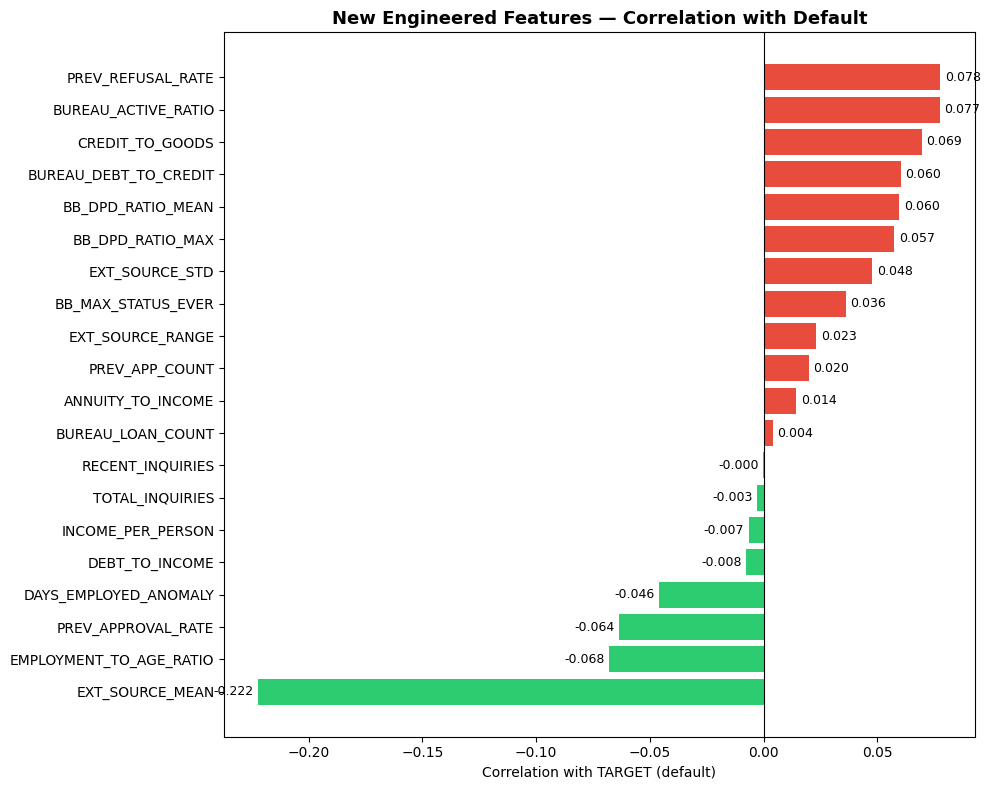


Top 5 positively correlated new features:
BB_DPD_RATIO_MEAN       0.0597
BUREAU_DEBT_TO_CREDIT   0.0602
CREDIT_TO_GOODS         0.0694
BUREAU_ACTIVE_RATIO     0.0774
PREV_REFUSAL_RATE       0.0777

Top 5 negatively correlated new features:
EXT_SOURCE_MEAN           -0.2221
EMPLOYMENT_TO_AGE_RATIO   -0.0680
PREV_APPROVAL_RATE        -0.0635
DAYS_EMPLOYED_ANOMALY     -0.0460
DEBT_TO_INCOME            -0.0077


In [7]:
print("=" * 50)
print("NEW FEATURES CORRELATION WITH TARGET")
print("=" * 50)

new_feature_cols = [
    "DEBT_TO_INCOME", "ANNUITY_TO_INCOME", "CREDIT_TO_GOODS",
    "INCOME_PER_PERSON", "EXT_SOURCE_MEAN", "EXT_SOURCE_STD",
    "EXT_SOURCE_RANGE", "EMPLOYMENT_TO_AGE_RATIO",
    "TOTAL_INQUIRIES", "RECENT_INQUIRIES",
    "BUREAU_LOAN_COUNT", "BUREAU_ACTIVE_RATIO",
    "BUREAU_DEBT_TO_CREDIT", "BB_MAX_STATUS_EVER",
    "BB_DPD_RATIO_MAX", "BB_DPD_RATIO_MEAN",
    "PREV_APPROVAL_RATE", "PREV_REFUSAL_RATE",
    "PREV_APP_COUNT", "DAYS_EMPLOYED_ANOMALY"
]

corr_new = df_final[new_feature_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
corr_new = corr_new.sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if x > 0 else "#2ecc71" for x in corr_new.values]
bars = ax.barh(range(len(corr_new)), corr_new.values, color=colors)
ax.set_yticks(range(len(corr_new)))
ax.set_yticklabels(corr_new.index, fontsize=10)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with TARGET (default)")
ax.set_title("New Engineered Features — Correlation with Default",
             fontsize=13, fontweight="bold")

for i, val in enumerate(corr_new.values):
    ax.text(val + (0.002 if val > 0 else -0.002), i,
            f"{val:.3f}", va="center",
            ha="left" if val > 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "07_new_features_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 positively correlated new features:")
print(corr_new.tail(5).round(4).to_string())
print("\nTop 5 negatively correlated new features:")
print(corr_new.head(5).round(4).to_string())

In [8]:
print("=" * 50)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 50)

print(f"""
FEATURES CREATED
----------------
Core financial ratios:     20 features
  • AGE_YEARS, EMPLOYMENT_YEARS
  • DEBT_TO_INCOME, ANNUITY_TO_INCOME
  • EXT_SOURCE_MEAN/STD/MIN/MAX/RANGE
  • TOTAL_INQUIRIES, RECENT_INQUIRIES

Bureau features:           17 features
  • BUREAU_LOAN_COUNT, BUREAU_ACTIVE_RATIO
  • BUREAU_DEBT_TO_CREDIT, BUREAU_TOTAL_OVERDUE
  • BB_MAX_STATUS_EVER, BB_DPD_RATIO_MAX

Previous application:      14 features
  • PREV_APP_COUNT, PREV_APPROVAL_RATE
  • PREV_REFUSAL_RATE, PREV_AMT_CREDIT_MEAN

TOTAL NEW FEATURES:        51
TOTAL FEATURES:            173

TOP PREDICTIVE NEW FEATURES
---------------------------
1. EXT_SOURCE_MEAN        corr = -0.2221
2. PREV_REFUSAL_RATE      corr = +0.0777
3. BUREAU_ACTIVE_RATIO    corr = +0.0774
4. CREDIT_TO_GOODS        corr = +0.0694
5. EMPLOYMENT_TO_AGE      corr = -0.0680
6. PREV_APPROVAL_RATE     corr = -0.0635
7. BB_DPD_RATIO_MEAN      corr = +0.0597

NEXT STEPS
----------
→ Handle missing values (67 columns need imputation)
→ Encode categorical features (16 columns)
→ Cap outliers (income, credit amounts)
→ Apply SMOTE for class imbalance
→ Save final preprocessed dataset
""")

# Verify saved file
save_path = PROCESSED_DIR / "02_feature_engineered.parquet"
df_loaded = pd.read_parquet(save_path)
print(f"Verified saved file: {df_loaded.shape}")
print(f"File size: {save_path.stat().st_size / 1024**2:.1f} MB")
print("\nFeature engineering complete!")

FEATURE ENGINEERING SUMMARY

FEATURES CREATED
----------------
Core financial ratios:     20 features
  • AGE_YEARS, EMPLOYMENT_YEARS
  • DEBT_TO_INCOME, ANNUITY_TO_INCOME
  • EXT_SOURCE_MEAN/STD/MIN/MAX/RANGE
  • TOTAL_INQUIRIES, RECENT_INQUIRIES

Bureau features:           17 features
  • BUREAU_LOAN_COUNT, BUREAU_ACTIVE_RATIO
  • BUREAU_DEBT_TO_CREDIT, BUREAU_TOTAL_OVERDUE
  • BB_MAX_STATUS_EVER, BB_DPD_RATIO_MAX

Previous application:      14 features
  • PREV_APP_COUNT, PREV_APPROVAL_RATE
  • PREV_REFUSAL_RATE, PREV_AMT_CREDIT_MEAN

TOTAL NEW FEATURES:        51
TOTAL FEATURES:            173

TOP PREDICTIVE NEW FEATURES
---------------------------
1. EXT_SOURCE_MEAN        corr = -0.2221
2. PREV_REFUSAL_RATE      corr = +0.0777
3. BUREAU_ACTIVE_RATIO    corr = +0.0774
4. CREDIT_TO_GOODS        corr = +0.0694
5. EMPLOYMENT_TO_AGE      corr = -0.0680
6. PREV_APPROVAL_RATE     corr = -0.0635
7. BB_DPD_RATIO_MEAN      corr = +0.0597

NEXT STEPS
----------
→ Handle missing values (67 